In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score, confusion_matrix,
                             classification_report)
data=pd.read_csv("data/customer_segmentation_v2.csv") 
data.head()

,CustomerID,Name,Age,Gender,City,Monthly_Income,Spending_Score,Avg_Order_Value,Discounts_Used,Customer_Segment
0,CUST1001,Suresh,39,Male,Mumbai,46664,61.3,2555,5,Impulse Buyer
1,CUST1002,Nisha,32,Female,Pune,150177,86.3,9734,0,Premium Buyer
2,CUST1003,Ramesh,24,Male,Bangalore,150540,82.3,9727,1,Premium Buyer
3,CUST1004,Sanjay,24,Female,Hyderabad,13799,85.8,414,11,Budget Buyer
4,CUST1005,Meena,59,Female,Pune,146908,83.4,10283,0,Premium Buyer


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        500 non-null    str    
 1   Name              500 non-null    str    
 2   Age               500 non-null    int64  
 3   Gender            500 non-null    str    
 4   City              500 non-null    str    
 5   Monthly_Income    500 non-null    int64  
 6   Spending_Score    500 non-null    float64
 7   Avg_Order_Value   500 non-null    int64  
 8   Discounts_Used    500 non-null    int64  
 9   Customer_Segment  500 non-null    str    
dtypes: float64(1), int64(4), str(5)
memory usage: 39.2 KB


In [5]:
data.isna().sum()

CustomerID          0
Name                0
Age                 0
Gender              0
City                0
Monthly_Income      0
Spending_Score      0
Avg_Order_Value     0
Discounts_Used      0
Customer_Segment    0
dtype: int64

In [7]:
features = [
    "Monthly_Income",   # Biggest separator between segments
    "Spending_Score",   # How freely they spend
    "Avg_Order_Value",  # Size of each purchase
    "Discounts_Used"    # Buying behavior
]
 
X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
wcss = []
K_range = range(1, 11)
 
for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

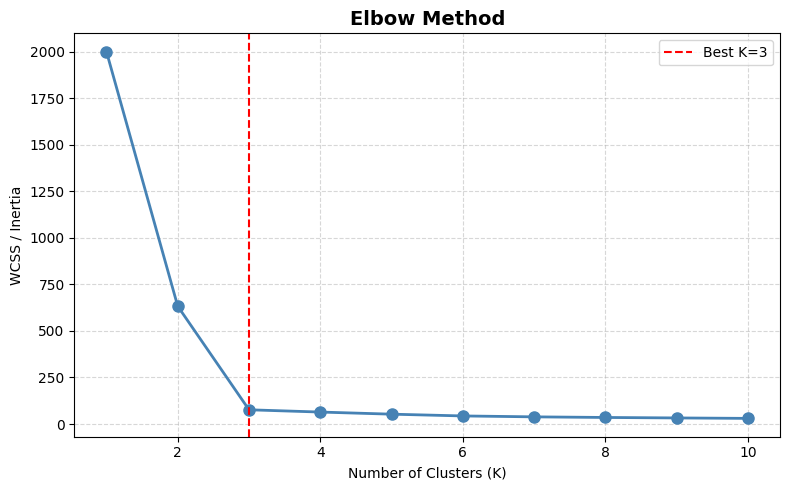

In [9]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
 
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Best K=3')
plt.title("Elbow Method", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("elbow_v2.png", dpi=150)
plt.show()

In [10]:
print("\nSilhouette Scores:")
print("=" * 40)
best_k, best_score = 2, 0
for k in range(2, 11):
    labels = KMeans(n_clusters=k, init="k-means++",
                    random_state=42, n_init=10).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    bar = "█" * int(score * 40)
    flag = " ← 🏆 BEST!" if score > best_score else ""
    print(f"  K={k}  →  {score:.4f}  {bar}{flag}")
    if score > best_score:
        best_score = score
        best_k = k
print("=" * 40)
print(f"\n✅ Best K = {best_k}  |  Best Silhouette = {best_score:.4f}")


Silhouette Scores:
  K=2  →  0.6787  ███████████████████████████ ← 🏆 BEST!
  K=3  →  0.8217  ████████████████████████████████ ← 🏆 BEST!
  K=4  →  0.6705  ██████████████████████████
  K=5  →  0.5285  █████████████████████
  K=6  →  0.3646  ██████████████
  K=7  →  0.3641  ██████████████
  K=8  →  0.3424  █████████████
  K=9  →  0.3164  ████████████
  K=10  →  0.3209  ████████████

✅ Best K = 3  |  Best Silhouette = 0.8217


In [12]:
kmeans = KMeans(n_clusters=best_k, init="k-means++", random_state=42, n_init=10)
data["Cluster"] = kmeans.fit_predict(X_scaled)
 
# Assign labels by sorting income (low → mid → high)
income_order = data.groupby("Cluster")["Monthly_Income"].mean().sort_values()
sorted_clusters = income_order.index.tolist()
label_map = {
    sorted_clusters[0]: "💰 Budget Buyer",
    sorted_clusters[1]: "🛍️ Impulse Buyer",
    sorted_clusters[2]: "👑 Premium Buyer"
}
data["Predicted_Segment"] = data["Cluster"].map(label_map)

C:\Users\Chirrareddy\AppData\Local\Temp\ipykernel_16836\3521787090.py:22: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Chirrareddy\AppData\Local\Temp\ipykernel_16836\3521787090.py:22: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Chirrareddy\AppData\Local\Temp\ipykernel_16836\3521787090.py:22: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Chirrareddy\AppData\Local\Temp\ipykernel_16836\3521787090.py:23: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig("scatter_v2.png", dpi=150)
C:\Users\Chirrareddy\AppData\Local\Temp\ipykernel_16836\3521787090.py:23: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) DejaVu Sans.
  plt.savefig("scatter_v2.png", dpi=150)
C:\Users\Chirrareddy\AppData\Local\Temp\ipykernel_16836\3521787090.py:23: UserWarning: Glyph 128081 (

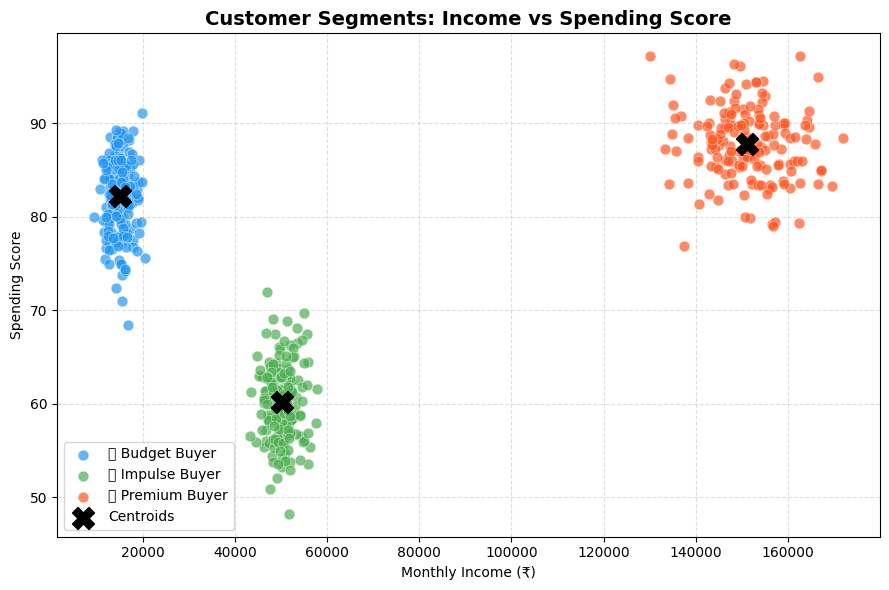

In [85]:
plt.figure(figsize=(9, 6))
colors = {"💰 Budget Buyer": "#2196F3",
          "🛍️ Impulse Buyer": "#4CAF50",
          "👑 Premium Buyer": "#FF5722"}
 
for label, color in colors.items():
    subset = data[data["Predicted_Segment"] == label]
    plt.scatter(subset["Monthly_Income"], subset["Spending_Score"],
                c=color, label=label, alpha=0.7, s=60,
                edgecolors='white', linewidths=0.4)
 
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)
plt.scatter(centers_df["Monthly_Income"], centers_df["Spending_Score"],
            c='black', marker='X', s=250, zorder=5, label='Centroids')
 
plt.title("Customer Segments: Income vs Spending Score", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Income (₹)")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("scatter_v2.png", dpi=150)
plt.show()

In [88]:
print("\n" + "=" * 50)
print("           FINAL CLUSTER SUMMARY")
print("=" * 50)
for cluster_id, label in label_map.items():
    sub = data[data["Cluster"] == cluster_id]
    print(f"\n{label}")
    print(f"  Total Customers    : {len(sub)}")
    print(f"  Avg Monthly Income : ₹{sub['Monthly_Income'].mean():,.0f}")
    print(f"  Avg Spending Score : {sub['Spending_Score'].mean():.1f}")
    print(f"  Avg Order Value    : ₹{sub['Avg_Order_Value'].mean():,.0f}")
    print(f"  Avg Discounts Used : {sub['Discounts_Used'].mean():.1f}")
print("=" * 50)
 
data.to_csv("customer_segmentation_v2_results.csv", index=False)
print("\n✅ Results saved to customer_segmentation_v2_results.csv")


           FINAL CLUSTER SUMMARY

💰 Budget Buyer
  Total Customers    : 177
  Avg Monthly Income : ₹14,999
  Avg Spending Score : 82.2
  Avg Order Value    : ₹399
  Avg Discounts Used : 11.6

🛍️ Impulse Buyer
  Total Customers    : 165
  Avg Monthly Income : ₹50,217
  Avg Spending Score : 60.2
  Avg Order Value    : ₹2,498
  Avg Discounts Used : 3.6

👑 Premium Buyer
  Total Customers    : 158
  Avg Monthly Income : ₹151,121
  Avg Spending Score : 87.9
  Avg Order Value    : ₹10,047
  Avg Discounts Used : 0.6

✅ Results saved to customer_segmentation_v2_results.csv
